In [3]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
# Input Paths
DATA_DIR = r""
TEST_IMAGES_DIR = r""
SAMPLE_CSV_PATH = r"" # The file with IDs and empty labels

# Output Path
OUTPUT_CSV_PATH = '/kaggle/working/predictions.csv'

2026-04-25 19:59:31.437491: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777147171.619813      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777147171.675037      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777147172.116159      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777147172.116204      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777147172.116207      55 computation_placer.cc:177] computation placer alr

Found 633 images belonging to 7 classes.
Found 155 images belonging to 7 classes.

Starting Training...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-25 19:59:53.748209: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - accuracy: 0.2026 - loss: 2.2411 - val_accuracy: 0.2581 - val_loss: 1.9037
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - accuracy: 0.2984 - loss: 1.8592 - val_accuracy: 0.3226 - val_loss: 1.8554
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - accuracy: 0.3592 - loss: 1.6865 - val_accuracy: 0.3097 - val_loss: 1.9651
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.3939 - loss: 1.4557 - val_accuracy: 0.3613 - val_loss: 2.0232
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.5346 - loss: 1.2712 - val_accuracy: 0.4645 - val_loss: 1.8704
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - accuracy: 0.5428 - loss: 1.0964 - val_accuracy: 0.5290 - val_loss: 1.6251
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.6947 - loss: 0.8734 - val_accuracy: 0.5419 - val_loss: 1.5723
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.7745 - loss: 0.6477 - val_accuracy: 0.

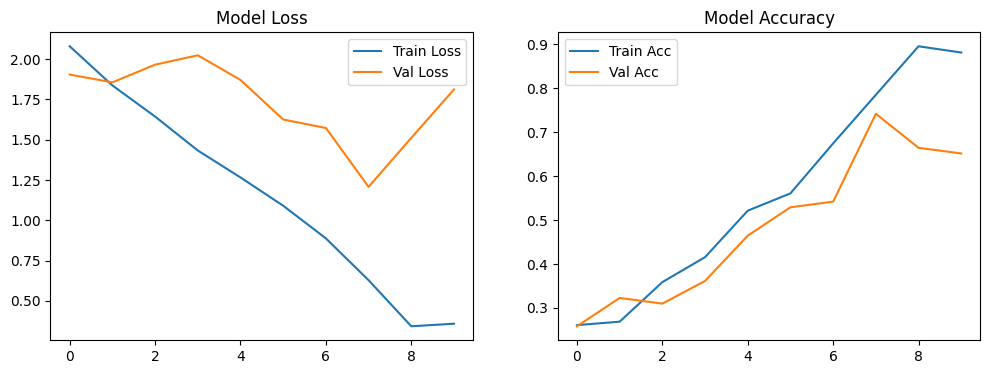


Generating predictions for 193 images...

✅ All tasks complete. File saved to: /kaggle/working/predictions.csv


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import f1_score


SEED = 25
np.random.seed(SEED)
tf.random.set_seed(SEED)
# replace by you img size, eg: (128, 128)
IMG_SIZE = (128, 128) 
BATCH_SIZE = 32
EPOCHS = 10
LR = 0.01

# Initialize generator with 20% validation split
datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_ds = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_ds = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

num_classes = len(train_ds.class_indices)

# MODEL ARCHITECTURE
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(num_classes, activation='softmax')
])

opt = tf.keras.optimizers.Adam(learning_rate=LR)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
print("\nStarting Training...")
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Model Loss')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Model Accuracy')
ax2.legend()
plt.show()

submission_df = pd.read_csv(SAMPLE_CSV_PATH)
predicted_labels = []

for i, row in submission_df.iterrows():
    img_id = row['id']
    img_path = os.path.join(TEST_IMAGES_DIR, img_id)
    
    if os.path.exists(img_path):
        img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
        img_array = tf.keras.utils.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        # Predict class index
        pred = model.predict(img_array, verbose=0)
        predicted_labels.append(np.argmax(pred))
    else:
        print("not found.")

submission_df['label'] = predicted_labels
submission_df.to_csv(OUTPUT_CSV_PATH, index=False)
print("File saved")